In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
# Load dataset
df = pd.read_csv('dataset.csv')   # make sure path is correct

# Extract features
X = df[['x', 'y']].values

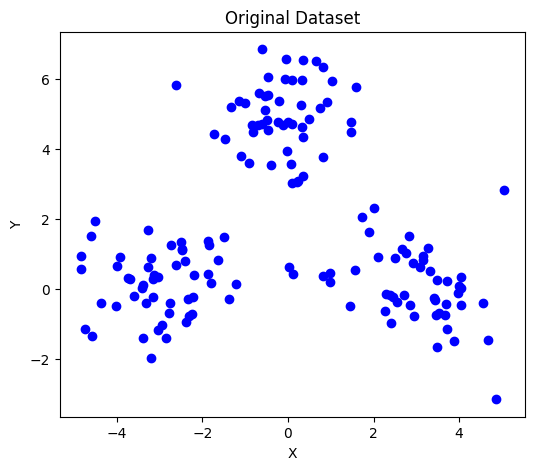

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], color='blue')
plt.title("Original Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

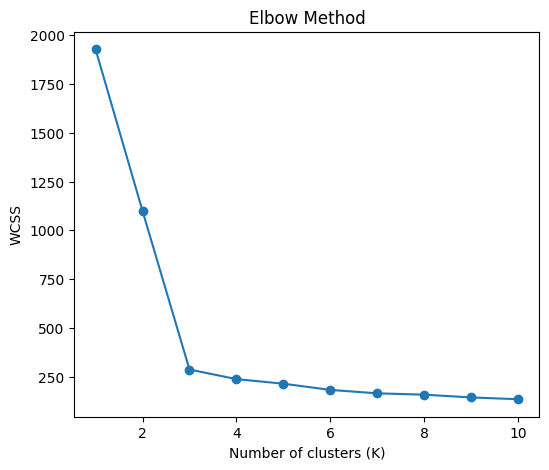

In [ ]:
wcss = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)   # inertia_ = WCSS

# Plot Elbow Graph
plt.figure(figsize=(6,5))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

In [ ]:
optimal_k = 3   # <-- change this based on elbow graph

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X)

centroids = kmeans.cluster_centers_

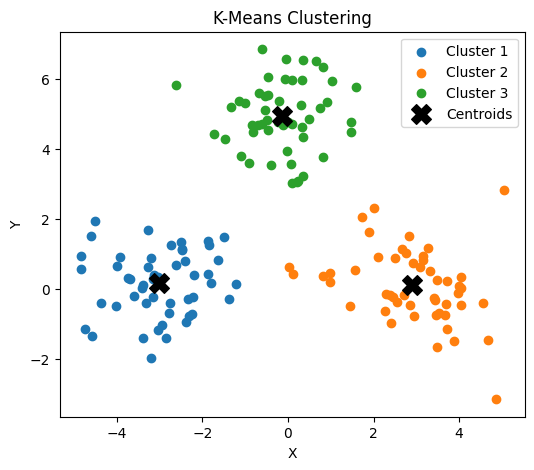

In [ ]:
plt.figure(figsize=(6,5))

# Plot each cluster
for i in range(optimal_k):
    plt.scatter(X[y_kmeans == i, 0],
                X[y_kmeans == i, 1],
                label=f'Cluster {i+1}')

# Plot centroids
plt.scatter(centroids[:, 0],
            centroids[:, 1],
            s=200,
            c='black',
            marker='X',
            label='Centroids')

plt.title("K-Means Clustering")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
print("Centroids:\n", centroids)
print("Final WCSS:", kmeans.inertia_)
print("Iterations until convergence:", kmeans.n_iter_)

Centroids:
 [[-3.01464554  0.1625205 ]
 [ 2.90065318  0.10041663]
 [-0.13567563  4.9279826 ]]
Final WCSS: 286.65854230851454
Iterations until convergence: 2
